**Importing the required Libraries**

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [60]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Reading the dataset**

In [61]:
data_2022 = pd.read_csv("/content/drive/MyDrive/SCF_data/SCFP2022.csv")
data_2022.head()

,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
0,1,11,3027.956120,2,70,5,9,3,2,2,...,4,2,4,2,1,8,3,3,2,1
1,1,12,3054.900065,2,70,5,9,3,2,2,...,4,2,5,2,1,8,3,3,2,1
2,1,13,3163.637766,2,70,5,9,3,2,2,...,4,2,4,2,1,8,3,3,1,1
3,1,14,3166.228463,2,70,5,9,3,2,2,...,3,2,4,1,1,6,3,2,1,1
4,1,15,3235.624715,2,70,5,9,3,2,2,...,3,2,4,2,1,8,3,3,1,1


In [62]:
data_2022.shape

(22975, 357)

In [63]:
map_2022 = pd.read_excel("/content/drive/MyDrive/SCF_data/2022map.xlsx")
map_2022.head()

,J14,Unnamed: 1,6.1,6,6.1
0,J19,NaN,6.1,6,12
1,J100,NaN,6.1,6,18
2,J101,NaN,6.1,6,24
3,J102,NaN,6.1,6,30
4,J103,NaN,6.1,6,36


In [64]:
# All the variables needed for the analysis

variables_required = {

    'identifiers': ['Y1', 'YY1', 'WGT'],

    'treatment': ['BNPL', 'NOBNPL'],

    'outcomes': [

        # Debt composition
        'CCBAL',        # Credit card balance
        'DEBT',         # Total debt
        'INSTALL',      # Installment loans
        'DEBT2INC',     # Debt-to-income ratio
        'LEVRATIO',     # Leverage ratio

        # Liquidity
        'LIQ',          # Liquid assets
        'CHECKING',     # Checking balance
        'SAVING',       # Savings balance

        # Financial stress
        'LATE',         # Any late payment
        'LATE60',       # 60+ days late
        'HPAYDAY',      # Payday loan use
    ],


    'demographics': [
        'AGE',          # Age (continuous)
        'AGECL',        # Age category
        'HHSEX',        # Gender
        'EDCL',         # Education category
        'MARRIED',      # Marital status
        'KIDS',         # Number of children
        'RACECL',       # Race category
        'RACE',          # Race
        'LF',           # Labor force status
        'FAMSTRUCT',    # Family structure
        'OCCAT1',       # Occupation category
        'OCCAT2',       # Occupation sub-category
    ],

    'financial': [
        'INCOME',       # Total income
        'INCCAT',       # Income percentile
        'NETWORTH',     # Net worth
        'NWCAT',        # Net worth category
        'ASSET',        # Total assets
        'FIN',          # Financial assets
        'HOUSES',       # Home value
        'HOUSECL',      # Homeowner status
    ],

    'credit_access': [
        'TURNDOWN',     # Denied credit
        'FEARDENIAL',   # Feared denial
        'TURNFEAR',     # Either (combined)
        'BNKRUPLAST5',  # Recent bankruptcy
        'NOCHK',        # Unbanked
    ],

    'behavioral': [
        'FINLIT',       # Financial literacy
        'YESFINRISK',   # Risk tolerance
        'SAVED',        # Saved last year
        'SPENDMOR',     # Spending > income
        'BINTERNET',    # Uses internet for borrowing
    ],
}


In [65]:
vars_needed = sorted(set(var for group in variables_required.values() for var in group))
available_vars = set(data_2022.columns)

missing_vars = sorted([v for v in vars_needed if v not in available_vars])
present_vars = sorted([v for v in vars_needed if v in available_vars])

print(f"Variables found: {len(present_vars)}")
print(f"Variables missing: {len(missing_vars)}")



Variables found: 46
Variables missing: 0


In [66]:
missing_vars

[]

In [67]:
data_2022_filtered = data_2022[present_vars].copy()

In [68]:
data_2022_filtered

,AGE,AGECL,ASSET,BINTERNET,BNKRUPLAST5,BNPL,CCBAL,CHECKING,DEBT,DEBT2INC,...,RACECL,SAVED,SAVING,SPENDMOR,TURNDOWN,TURNFEAR,WGT,Y1,YESFINRISK,YY1
0,70,5,957100.0,1,0,0,0,6700,195000,5.025160,...,1,1,6400,5,0,0,3027.956120,11,0,1
1,70,5,1067300.0,1,0,0,0,4200,213000,5.566549,...,1,1,3100,5,0,0,3054.900065,12,0,1
2,70,5,957200.0,1,0,0,0,3200,279000,7.728006,...,1,1,0,5,0,0,3163.637766,13,0,1
3,70,5,828600.0,1,0,0,0,2600,549000,16.384017,...,1,1,49000,5,0,0,3166.228463,14,0,1
4,70,5,825600.0,1,0,0,0,1800,223000,6.270739,...,1,1,5800,5,0,0,3235.624715,15,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22970,40,2,0.0,1,0,0,0,0,0,0.000000,...,2,0,0,1,0,1,1705.225499,46031,0,4603
22971,40,2,0.0,1,0,0,0,0,0,0.000000,...,2,0,0,5,0,1,1713.918975,46032,0,4603
22972,40,2,0.0,1,0,0,0,0,0,0.000000,...,2,0,0,5,0,1,1689.140933,46033,0,4603
22973,40,2,0.0,1,0,0,0,0,0,0.000000,...,2,0,0,5,0,1,1714.060239,46034,0,4603


**Exploratory Data Analysis**

In [69]:
df_eda = data_2022_filtered[data_2022_filtered["Y1"] % 10 == 1].copy()

In [70]:
df_eda

,AGE,AGECL,ASSET,BINTERNET,BNKRUPLAST5,BNPL,CCBAL,CHECKING,DEBT,DEBT2INC,...,RACECL,SAVED,SAVING,SPENDMOR,TURNDOWN,TURNFEAR,WGT,Y1,YESFINRISK,YY1
0,70,5,957100.0,1,0,0,0,6700,195000,5.025160,...,1,1,6400,5,0,0,3027.956120,11,0,1
5,46,3,1240500.0,1,0,0,700,5500,518700,2.307080,...,1,1,35000,3,0,0,236.634754,21,0,2
10,68,5,61177590.0,1,0,0,0,1880,17580000,39.475841,...,1,1,3310,3,0,0,678.869307,31,0,3
15,74,5,2203000.0,0,0,0,0,14000,0,0.000000,...,1,1,150000,3,0,0,621.948854,41,0,4
20,19,1,15100.0,1,0,0,0,0,11000,0.195704,...,2,1,0,2,1,1,7191.481109,51,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22950,55,4,7295000.0,0,0,0,0,4000,583000,0.308205,...,1,1,0,2,0,0,735.127169,45991,0,4599
22955,50,3,773000.0,0,0,0,25150,2000,150150,0.958003,...,1,0,2000,5,0,1,13270.593405,46001,0,4600
22960,31,1,8480.0,0,0,500,41000,180,426620,2.281418,...,1,0,0,5,1,1,2000.955075,46011,0,4601
22965,56,4,288180.0,1,0,0,3150,330,65150,1.159100,...,1,1,450,3,0,0,12961.383097,46021,0,4602


In [71]:
# BNPL user indicator
df_eda["bnpl_user"] = (df_eda["BNPL"] > 0).astype(int)
df_eda

,AGE,AGECL,ASSET,BINTERNET,BNKRUPLAST5,BNPL,CCBAL,CHECKING,DEBT,DEBT2INC,...,SAVED,SAVING,SPENDMOR,TURNDOWN,TURNFEAR,WGT,Y1,YESFINRISK,YY1,bnpl_user
0,70,5,957100.0,1,0,0,0,6700,195000,5.025160,...,1,6400,5,0,0,3027.956120,11,0,1,0
5,46,3,1240500.0,1,0,0,700,5500,518700,2.307080,...,1,35000,3,0,0,236.634754,21,0,2,0
10,68,5,61177590.0,1,0,0,0,1880,17580000,39.475841,...,1,3310,3,0,0,678.869307,31,0,3,0
15,74,5,2203000.0,0,0,0,0,14000,0,0.000000,...,1,150000,3,0,0,621.948854,41,0,4,0
20,19,1,15100.0,1,0,0,0,0,11000,0.195704,...,1,0,2,1,1,7191.481109,51,0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22950,55,4,7295000.0,0,0,0,0,4000,583000,0.308205,...,1,0,2,0,0,735.127169,45991,0,4599,0
22955,50,3,773000.0,0,0,0,25150,2000,150150,0.958003,...,0,2000,5,0,1,13270.593405,46001,0,4600,0
22960,31,1,8480.0,0,0,500,41000,180,426620,2.281418,...,0,0,5,1,1,2000.955075,46011,0,4601,1
22965,56,4,288180.0,1,0,0,3150,330,65150,1.159100,...,1,450,3,0,0,12961.383097,46021,0,4602,0


In [72]:
n_households = df_eda["YY1"].nunique()
bnpl_rate = np.average(df_eda["bnpl_user"], weights=df_eda["WGT"])

print(f"Households (EDA sample): {n_households}")
print(f"Weighted BNPL usage rate: {bnpl_rate:.2%}")


Households (EDA sample): 4595
Weighted BNPL usage rate: 7.01%


Age Groups

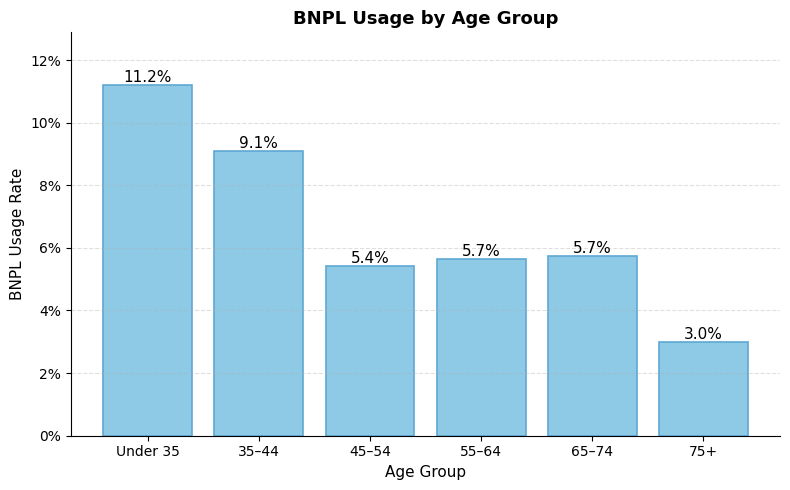

In [73]:
age_bnpl = (
    df_eda
    .groupby("AGECL")
    .apply(lambda x: np.average(x["bnpl_user"], weights=x["WGT"]))
)

age_labels = {
    1: "Under 35",
    2: "35–44",
    3: "45–54",
    4: "55–64",
    5: "65–74",
    6: "75+"
}

x_labels = [age_labels.get(i, str(i)) for i in age_bnpl.index]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    x_labels,
    age_bnpl.values,
    color="#8ECae6",
    edgecolor="#5FA8D3",
    linewidth=1.2
)

plt.ylabel("BNPL Usage Rate", fontsize=11)
plt.xlabel("Age Group", fontsize=11)
plt.title("BNPL Usage by Age Group", fontsize=13, weight="bold")

plt.ylim(0, age_bnpl.max() * 1.15)
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.01%}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()



Income groups

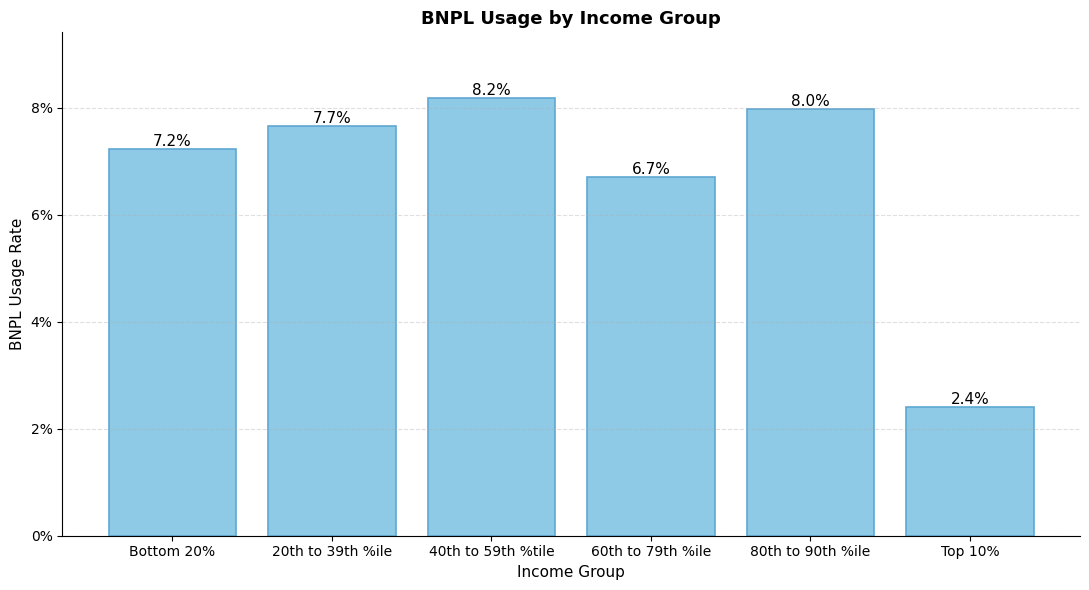

In [74]:
inc_bnpl = (
    df_eda
    .groupby("INCCAT")
    .apply(lambda x: np.average(x["bnpl_user"], weights=x["WGT"]))
)

inc_labels = {
    1: "Bottom 20%",
    2: "20th to 39th %ile",
    3: "40th to 59th %tile",
    4: "60th to 79th %ile",
    5: "80th to 90th %ile",
    6: "Top 10%"
}

x_labels = [inc_labels.get(i, str(i)) for i in inc_bnpl.index]

plt.figure(figsize=(11, 6))

bars = plt.bar(
    x_labels,
    inc_bnpl.values,
    color="#8ECae6",
    edgecolor="#5FA8D3",
    linewidth=1.2
)


plt.ylabel("BNPL Usage Rate", fontsize=11)
plt.xlabel("Income Group", fontsize=11)
plt.title("BNPL Usage by Income Group", fontsize=13, weight="bold")


plt.ylim(0, inc_bnpl.max() * 1.15)
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")


plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.grid(axis="x", visible=False)


for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.01%}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()


Credit Card Balance

In [75]:
df_eda["CCBAL"].min(),df_eda["CCBAL"].max()

(0, 139000)

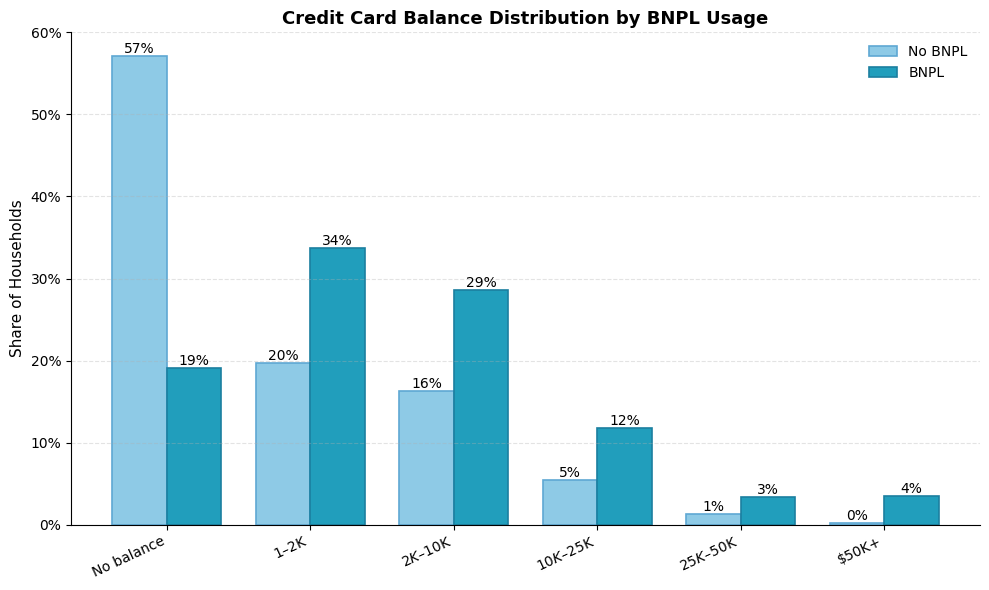

In [76]:
bins = [-1, 0, 2000, 10000, 25000, 50000, np.inf]
labels = [
    "No balance",
    "$1–$2K",
    "$2K–$10K",
    "$10K–$25K",
    "$25K–$50K",
    "$50K+",
]

df_eda["ccbal_bucket"] = pd.cut(
    df_eda["CCBAL"].fillna(0),
    bins=bins,
    labels=labels
)


bucket_bnpl = (
    df_eda
    .groupby(["bnpl_user", "ccbal_bucket"], observed=True)
    .apply(lambda x: np.sum(x["WGT"]))
    .reset_index(name="wgt_sum")
)

bucket_bnpl["share"] = (
    bucket_bnpl
    .groupby("bnpl_user")["wgt_sum"]
    .transform(lambda x: x / x.sum())
)

pivot = bucket_bnpl.pivot(index="ccbal_bucket", columns="bnpl_user", values="share")
pivot.columns = ["No BNPL", "BNPL"]


fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(pivot.index))
width = 0.38

ax.bar(x - width/2, pivot["No BNPL"], width,
       color="#8ECae6", edgecolor="#5FA8D3", linewidth=1.2, label="No BNPL")
ax.bar(x + width/2, pivot["BNPL"], width,
       color="#219EBC", edgecolor="#1B7FA0", linewidth=1.2, label="BNPL")

ax.set_ylabel("Share of Households", fontsize=11)
ax.set_title("Credit Card Balance Distribution by BNPL Usage", fontsize=13, weight="bold")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index.astype(str), rotation=25, ha="right", fontsize=10)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# annotate bars with % labels
for i, val in enumerate(pivot["No BNPL"].values):
    ax.text(i - width/2, val, f"{val:.0%}", ha="center", va="bottom", fontsize=10)
for i, val in enumerate(pivot["BNPL"].values):
    ax.text(i + width/2, val, f"{val:.0%}", ha="center", va="bottom", fontsize=10)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Debt

In [77]:
df_eda["DEBT"].min(),df_eda["DEBT"].max()

(0, 123890000)

In [78]:
# total debt buckets
bins = [-1, 0, 50_000, 250_000, 1_000_000, 10_000_000, np.inf]
labels = [
    "No debt",
    "$1–$50K",
    "$50K–$250K",
    "$250K–$1M",
    "$1M–$10M",
    "$10M+",
]

df_eda["debt_bucket"] = pd.cut(
    df_eda["DEBT"].fillna(0),
    bins=bins,
    labels=labels
)


In [79]:
debt_bucket_bnpl = (
    df_eda
    .groupby(["bnpl_user", "debt_bucket"], observed=True)
    .apply(lambda x: np.sum(x["WGT"]))
    .reset_index(name="wgt_sum")
)

debt_bucket_bnpl["share"] = (
    debt_bucket_bnpl
    .groupby("bnpl_user")["wgt_sum"]
    .transform(lambda x: x / x.sum())
)

pivot = debt_bucket_bnpl.pivot(
    index="debt_bucket",
    columns="bnpl_user",
    values="share"
)

pivot.columns = ["No BNPL", "BNPL"]


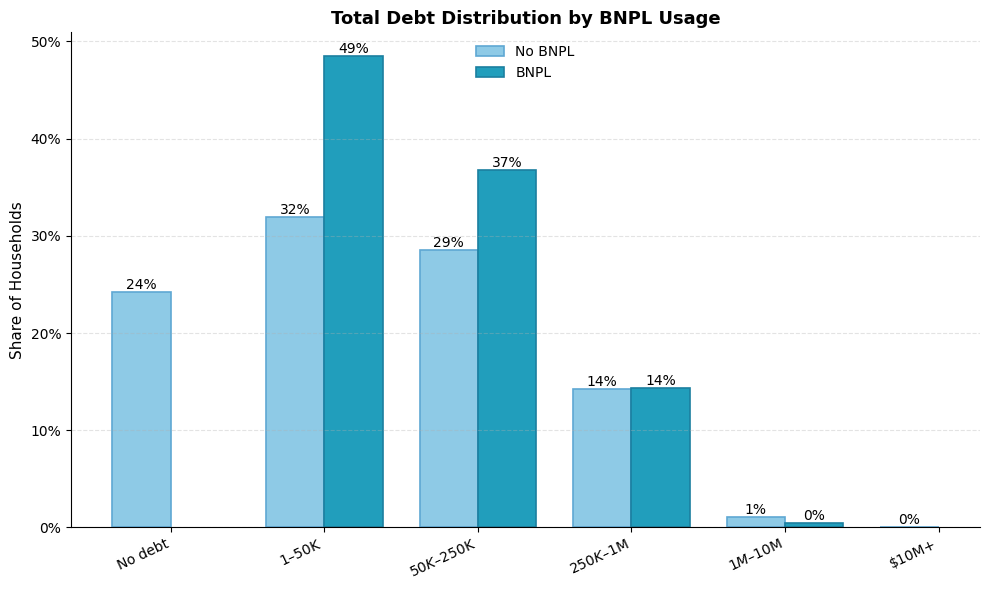

In [80]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(pivot.index))
width = 0.38

ax.bar(
    x - width/2,
    pivot["No BNPL"],
    width,
    color="#8ECae6",
    edgecolor="#5FA8D3",
    linewidth=1.2,
    label="No BNPL",
)

ax.bar(
    x + width/2,
    pivot["BNPL"],
    width,
    color="#219EBC",
    edgecolor="#1B7FA0",
    linewidth=1.2,
    label="BNPL",
)

ax.set_ylabel("Share of Households", fontsize=11)
ax.set_title("Total Debt Distribution by BNPL Usage", fontsize=13, weight="bold")

ax.set_xticks(x)
ax.set_xticklabels(pivot.index.astype(str), rotation=25, ha="right", fontsize=10)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)


for i, val in enumerate(pivot["No BNPL"].values):
    ax.text(i - width/2, val, f"{val:.0%}", ha="center", va="bottom", fontsize=10)
for i, val in enumerate(pivot["BNPL"].values):
    ax.text(i + width/2, val, f"{val:.0%}", ha="center", va="bottom", fontsize=10)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Misc Plots

In [81]:
FILL = "#8ECae6"
EDGE = "#5FA8D3"

def weighted_rate(df, y="bnpl_user", w="WGT"):
    return np.average(df[y], weights=df[w])

def bnpl_rate_by_group(df, group_col, label_map=None, dropna=True):
    tmp = df[[group_col, "bnpl_user", "WGT"]].copy()
    if dropna:
        tmp = tmp.dropna(subset=[group_col])
    rates = tmp.groupby(group_col).apply(lambda x: np.average(x["bnpl_user"], weights=x["WGT"]))
    rates = rates.sort_index(key=lambda s: s.astype(str))  # stable ordering for categorical codes
    if label_map is not None:
        rates.index = [label_map.get(k, str(k)) for k in rates.index]
    else:
        rates.index = rates.index.astype(str)
    return rates

def pretty_bar(series, title, xlabel):
    plt.figure(figsize=(9,5))
    bars = plt.bar(series.index, series.values, color=FILL, edgecolor=EDGE, linewidth=1.2)
    plt.ylabel("BNPL Usage Rate", fontsize=11)
    plt.xlabel(xlabel, fontsize=11)
    plt.title(title, fontsize=13, weight="bold")
    plt.ylim(0, series.max()*1.2 if series.max() > 0 else 1)

    plt.gca().yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    plt.grid(axis="y", linestyle="--", alpha=0.35)
    plt.grid(axis="x", visible=False)
    for spine in ["top","right"]:
        plt.gca().spines[spine].set_visible(False)

    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h, f"{h:.1%}", ha="center", va="bottom", fontsize=10)

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


Comparison based on Household Head/Reference person Gender

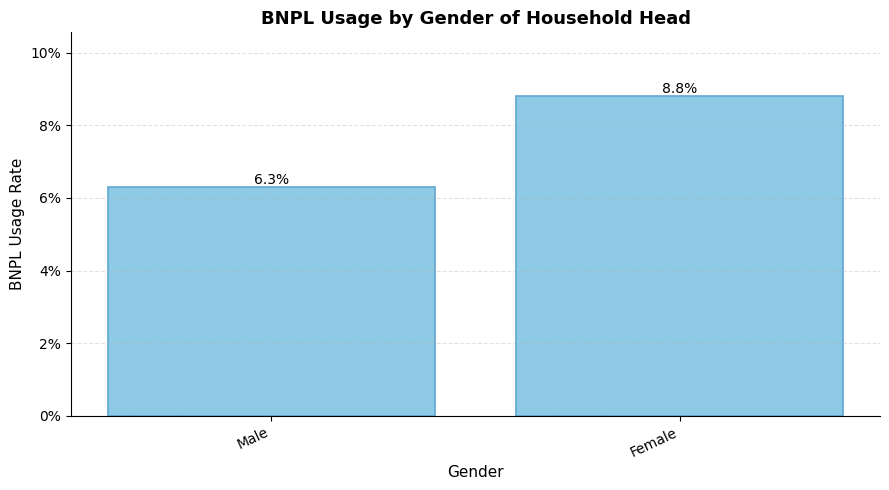

In [82]:
hhsex_map = {1: "Male", 2: "Female"}

s = bnpl_rate_by_group(df_eda, "HHSEX", label_map=hhsex_map)
pretty_bar(s, "BNPL Usage by Gender of Household Head", "Gender")


Comparison based on Race/Ethnicity

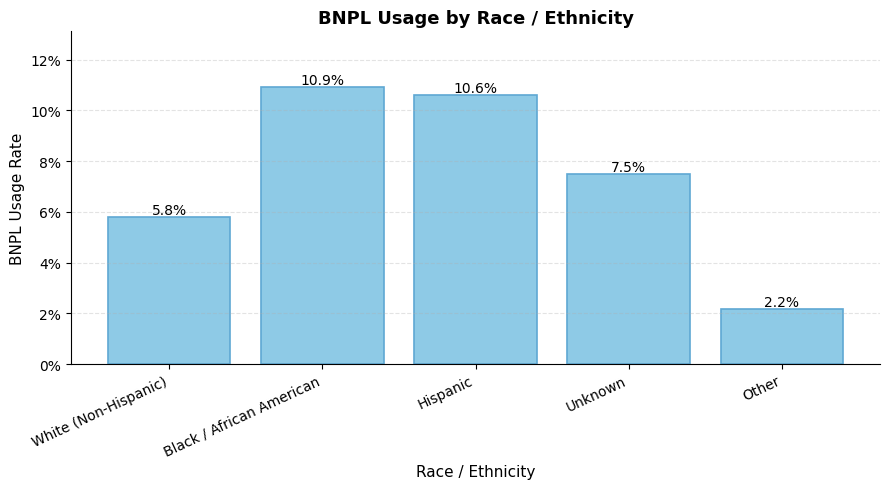

In [83]:
# RACE
race_map = {
    1: "White (Non-Hispanic)",
    2: "Black / African American",
    3: "Hispanic",
    4: "Unknown",
    5: "Other",
}

s = bnpl_rate_by_group(
    df_eda,
    group_col="RACE",
    label_map=race_map
)

pretty_bar(
    s,
    "BNPL Usage by Race / Ethnicity",
    "Race / Ethnicity"
)



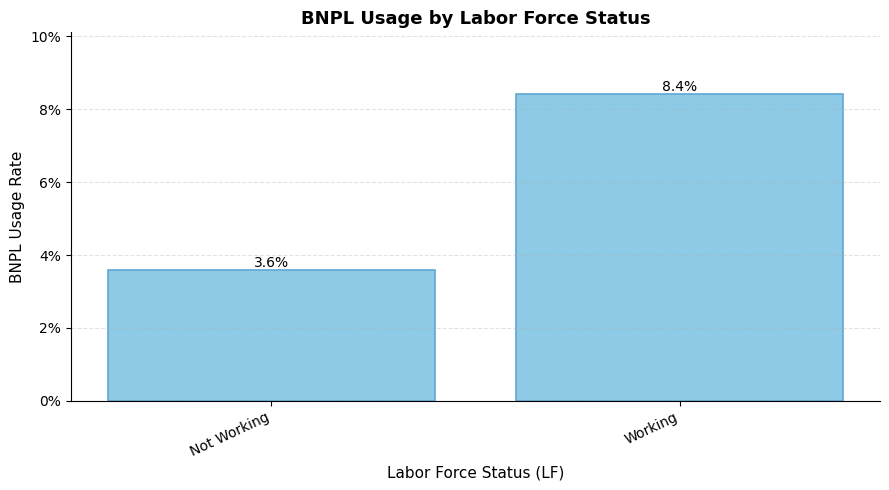

In [84]:
# labor force status
labor_map = {
    1: "Working",
    0: "Not Working"
}

s = bnpl_rate_by_group(df_eda, "LF", label_map=labor_map)
pretty_bar(s, "BNPL Usage by Labor Force Status", "Labor Force Status (LF)")


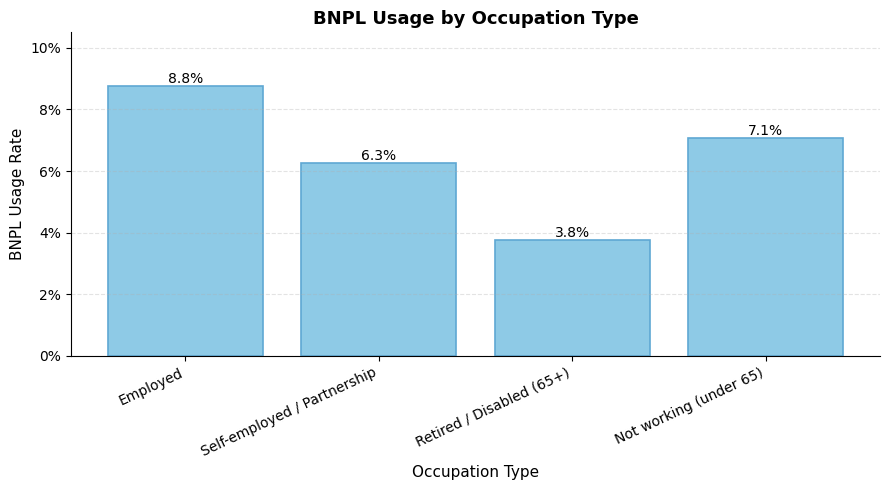

In [85]:
occat1_map = {
    1: "Employed",
    2: "Self-employed / Partnership",
    3: "Retired / Disabled (65+)",
    4: "Not working (under 65)",
}
s = bnpl_rate_by_group(
    df_eda,
    group_col="OCCAT1",
    label_map=occat1_map
)

pretty_bar(
    s,
    "BNPL Usage by Occupation Type",
    "Occupation Type"
)



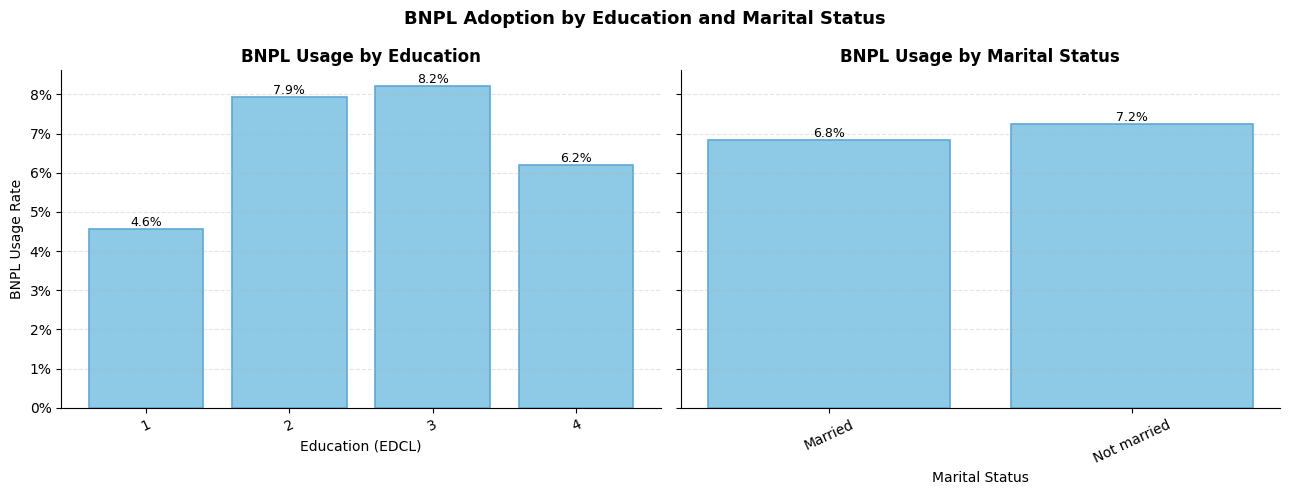

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(13,5), sharey=True)

# Education
edcl_map = None
ed = bnpl_rate_by_group(df_eda, "EDCL", label_map=edcl_map)
axes[0].bar(ed.index, ed.values, color=FILL, edgecolor=EDGE, linewidth=1.2)
axes[0].set_title("BNPL Usage by Education", fontsize=12, weight="bold")
axes[0].set_xlabel("Education (EDCL)")
axes[0].set_ylabel("BNPL Usage Rate")
axes[0].grid(axis="y", linestyle="--", alpha=0.35)
axes[0].grid(axis="x", visible=False)
for spine in ["top","right"]:
    axes[0].spines[spine].set_visible(False)
axes[0].tick_params(axis="x", rotation=25)

# Married
married_map = {1: "Married", 2: "Not married"}  # adjust if needed
mar = bnpl_rate_by_group(df_eda, "MARRIED", label_map=married_map)
axes[1].bar(mar.index, mar.values, color=FILL, edgecolor=EDGE, linewidth=1.2)
axes[1].set_title("BNPL Usage by Marital Status", fontsize=12, weight="bold")
axes[1].set_xlabel("Marital Status")
axes[1].grid(axis="y", linestyle="--", alpha=0.35)
axes[1].grid(axis="x", visible=False)
for spine in ["top","right"]:
    axes[1].spines[spine].set_visible(False)
axes[1].tick_params(axis="x", rotation=25)

# Y axis formatting
axes[0].yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")


for ax in axes:
    for p in ax.patches:
        h = p.get_height()
        ax.text(p.get_x() + p.get_width()/2, h, f"{h:.1%}", ha="center", va="bottom", fontsize=9)

plt.suptitle("BNPL Adoption by Education and Marital Status", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


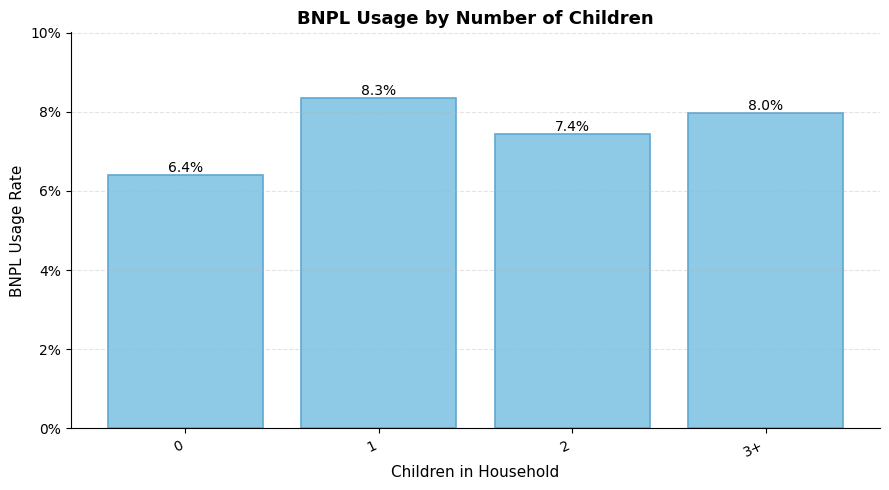

In [87]:
df_eda["kids_bucket"] = pd.cut(
    df_eda["KIDS"].fillna(0),
    bins=[-0.1, 0.1, 1.1, 2.1, np.inf],
    labels=["0", "1", "2", "3+"]
)

s = bnpl_rate_by_group(df_eda, "kids_bucket")
pretty_bar(s, "BNPL Usage by Number of Children", "Children in Household")


In [88]:
def weighted_mean(x, w):
    return np.sum(x * w) / np.sum(w)

liq_summary = (
    df_eda
    .groupby("bnpl_user")
    .apply(lambda x: pd.Series({
        "Checking": weighted_mean(x["CHECKING"].fillna(0), x["WGT"]),
        "Savings": weighted_mean(x["SAVING"].fillna(0), x["WGT"]),
    }))
)

liq_summary.index = ["No BNPL", "BNPL"]


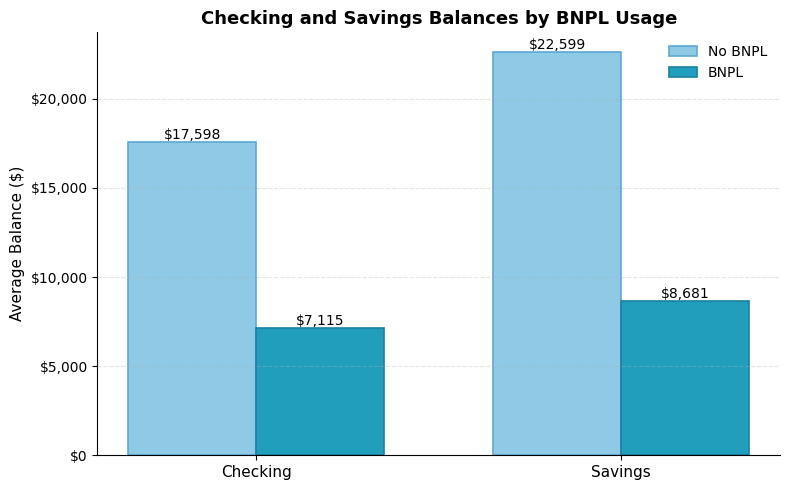

In [89]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(liq_summary.columns))
width = 0.35

ax.bar(
    x - width/2,
    liq_summary.loc["No BNPL"],
    width,
    label="No BNPL",
    color="#8ECae6",
    edgecolor="#5FA8D3",
    linewidth=1.2
)

ax.bar(
    x + width/2,
    liq_summary.loc["BNPL"],
    width,
    label="BNPL",
    color="#219EBC",
    edgecolor="#1B7FA0",
    linewidth=1.2
)

ax.set_xticks(x)
ax.set_xticklabels(liq_summary.columns, fontsize=11)
ax.set_ylabel("Average Balance ($)", fontsize=11)
ax.set_title("Checking and Savings Balances by BNPL Usage", fontsize=13, weight="bold")

ax.yaxis.set_major_formatter(lambda v, _: f"${v:,.0f}")

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Annotate bars
for i, col in enumerate(liq_summary.columns):
    ax.text(i - width/2, liq_summary.loc["No BNPL", col],
            f"${liq_summary.loc['No BNPL', col]:,.0f}",
            ha="center", va="bottom", fontsize=10)
    ax.text(i + width/2, liq_summary.loc["BNPL", col],
            f"${liq_summary.loc['BNPL', col]:,.0f}",
            ha="center", va="bottom", fontsize=10)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**Causal Analysis**

AIPW

In [90]:

# Data Preparation

def prepare_data(df):
    """
    Prepare SCF data for AIPW analysis.
    Creates treatment, transformations, and subgroup variables.
    """
    df = df.copy()


    # Treatment variable

    df['bnpl_user'] = (df['BNPL'] > 0).astype(int)


    # Log transformations for skewed variables

    df['log_income'] = np.log(df['INCOME'].clip(lower=1))
    df['log_liq'] = np.log(df['LIQ'].clip(lower=1) + 1)
    df['log_ccbal'] = np.log(df['CCBAL'].clip(lower=0) + 1)
    df['AGE_sq'] = df['AGE'] ** 2


    # Subgroup variables for heterogeneity analysis


    # Age (3 categories)
    df['age_group'] = pd.cut(
        df['AGECL'],
        bins=[0, 1, 3, 6],
        labels=['Under 35', '35-54', '55+']
    )

    # Income (3 categories)
    df['inc_group'] = pd.cut(
        df['INCCAT'],
        bins=[0, 2, 4, 6],
        labels=['Bottom 40%', 'Middle 40%', 'Top 20%']
    )

    # Education (2 categories)
    df['edu_group'] = np.where(
        df['EDCL'] >= 3,
        'College (Some/Degree)',
        'No College'
    )

    # Occupation (4 categories)
    df['occ_group'] = df['OCCAT1'].map({
        1: "Employed",
        2: "Self-employed / Partnership",
        3: "Retired / Disabled (65+)",
        4: "Not working (under 65)"
    })

    # Liquidity (2 categories: $5K threshold)
    df['liq_group'] = np.where(
        df['LIQ'] < 5000,
        'Low liquidity (<$5K)',
        'Has buffer (≥$5K)'
    )

    # Credit access (2 categories)
    df['credit_group'] = df['TURNFEAR'].map({
        0: 'Unconstrained',
        1: 'Constrained'
    })

    # Family structure (2 categories)
    df['family_group'] = np.where(
        df['KIDS'] > 0,
        'Has Children',
        'No Children'
    )

    # Marital status (2 categories)
    df['married_group'] = np.where(
        df['MARRIED'] == 1,
        'Married',
        'Not Married'
    )

    return df


# Prepare data
df = prepare_data(data_2022_filtered)

print(f"Total observations: {len(df)}")
print(f"BNPL users: {df['bnpl_user'].sum()} ({100*df['bnpl_user'].mean():.1f}%)")
print(f"BNPL users per implicate: {df['bnpl_user'].sum() // 5}")



# Base covariates
COVARIATES_BASE = [
    'AGE', 'AGE_sq',           # Demographics (age + quadratic)
    'log_income',              # Financial position
    'TURNFEAR',                # Credit constraints
    'EDCL',                    # Education
    'OCCAT1',                  # Occupation
    'MARRIED',                 # Marital status
    'KIDS'                     # Children
]

# Outcome-specific covariates
COVARIATES_BY_OUTCOME = {
    'LATE':   COVARIATES_BASE + ['log_liq', 'log_ccbal'],
    'LATE60': COVARIATES_BASE + ['log_liq', 'log_ccbal'],
    'CCBAL':  COVARIATES_BASE + ['log_liq'],
    'DEBT':   COVARIATES_BASE + ['log_liq', 'log_ccbal'],
    'LIQ':    COVARIATES_BASE + ['log_ccbal'],
}


for outcome, covs in COVARIATES_BY_OUTCOME.items():
    COVARIATES_BY_OUTCOME[outcome] = [c for c in covs if c in df.columns]

print("\nCovariates by outcome:")
for outcome, covs in COVARIATES_BY_OUTCOME.items():
    print(f"  {outcome}: {len(covs)} covariates")
    if outcome in ['CCBAL', 'LIQ']:
        print(f"    (excluded: {'log_ccbal' if outcome == 'CCBAL' else 'log_liq'})")

# Outcomes (5 variables)
OUTCOMES = ['LATE', 'LATE60', 'CCBAL', 'DEBT', 'LIQ']
print(f"\nOutcomes ({len(OUTCOMES)}): {OUTCOMES}")

# Subgroup dimensions for heterogeneity (8 dimensions)
SUBGROUP_VARS = {
    'age_group': 'Age',
    'inc_group': 'Income',
    'liq_group': 'Liquidity',
    'edu_group': 'Education',
    'occ_group': 'Occupation',
    'credit_group': 'Credit Access',
    'family_group': 'Family Structure',
    'married_group': 'Marital Status'
}
print(f"Subgroup dimensions ({len(SUBGROUP_VARS)}): {list(SUBGROUP_VARS.values())}")



Total observations: 22975
BNPL users: 1345 (5.9%)
BNPL users per implicate: 269

Covariates by outcome:
  LATE: 10 covariates
  LATE60: 10 covariates
  CCBAL: 9 covariates
    (excluded: log_ccbal)
  DEBT: 10 covariates
  LIQ: 9 covariates
    (excluded: log_liq)

Outcomes (5): ['LATE', 'LATE60', 'CCBAL', 'DEBT', 'LIQ']
Subgroup dimensions (8): ['Age', 'Income', 'Liquidity', 'Education', 'Occupation', 'Credit Access', 'Family Structure', 'Marital Status']


In [91]:
print("\n" + "="*70)
print("OVERALL ATT ESTIMATES (AIPW)")
print("="*70)
print(f"{'Outcome':<10} {'ATT':>12} {'SE':>10} {'95% CI':<24} {'p-value':>10}")
print("-"*70)

aipw_overall = {}

for outcome in OUTCOMES:
    if outcome not in df.columns:
        print(f"{outcome:<10} — not found in data")
        continue

    covariates = COVARIATES_BY_OUTCOME[outcome]
    result = aipw_with_implicates(df, outcome, covariates)

    if result is not None:
        aipw_overall[outcome] = result

        sig = "***" if result['p_value'] < 0.01 else (
              "**" if result['p_value'] < 0.05 else (
              "*" if result['p_value'] < 0.1 else ""))
        ci = f"[{result['ci_lower']:.4f}, {result['ci_upper']:.4f}]"

        print(f"{outcome:<10} {result['estimate']:>12.4f} {result['se']:>10.4f} {ci:<24} {result['p_value']:>9.4f} {sig}")

print("-"*70)
print("*** p<0.01, ** p<0.05, * p<0.1")



OVERALL ATT ESTIMATES (AIPW)
Outcome             ATT         SE 95% CI                      p-value
----------------------------------------------------------------------
LATE             0.0415     0.0330 [-0.0232, 0.1062]           0.2085 
LATE60           0.0328     0.0257 [-0.0176, 0.0831]           0.2023 
CCBAL         5029.6015  1381.8093 [2321.2553, 7737.9476]      0.0003 ***
DEBT          8788.8882 13470.3680 [-17613.0330, 35190.8094]    0.5141 
LIQ          -5789.9299  9544.0916 [-24496.3494, 12916.4897]    0.5441 
----------------------------------------------------------------------
*** p<0.01, ** p<0.05, * p<0.1


In [92]:
# Heterogeneity Analysis


def run_full_hte(df, outcomes, covariates_by_outcome, subgroup_vars):

    all_results = []

    for outcome in outcomes:
        if outcome not in df.columns:
            continue

        # Get outcome-specific covariates
        covariates = covariates_by_outcome[outcome]

        print(f"\nProcessing {outcome} ({len(covariates)} covariates)...")

        # Overall
        overall = aipw_with_implicates(df, outcome, covariates)
        if overall:
            all_results.append({
                'Outcome': outcome,
                'Dimension': 'Overall',
                'Subgroup': 'All',
                'ATT': overall['estimate'],
                'SE': overall['se'],
                'CI_lower': overall['ci_lower'],
                'CI_upper': overall['ci_upper'],
                'p_value': overall['p_value'],
                'n_treated': overall['n_treated']
            })

        # By subgroup
        for var, label in subgroup_vars.items():
            if var not in df.columns:
                continue

            print(f"  - {label}")
            cates = aipw_cate_by_subgroup(df, outcome, covariates, var)

            for group, result in cates.items():
                all_results.append({
                    'Outcome': outcome,
                    'Dimension': label,
                    'Subgroup': group,
                    'ATT': result['estimate'],
                    'SE': result['se'],
                    'CI_lower': result['ci_lower'],
                    'CI_upper': result['ci_upper'],
                    'p_value': result['p_value'],
                    'n_treated': result.get('n_treated_subgroup', result['n_treated'])
                })

    return pd.DataFrame(all_results)

print("\n" + "="*70)
print("RUNNING FULL HETEROGENEITY ANALYSIS")
print("="*70)

# Pass the outcome-specific covariates dictionary
results_df = run_full_hte(df, OUTCOMES, COVARIATES_BY_OUTCOME, SUBGROUP_VARS)

results_df['Sig'] = results_df['p_value'].apply(
    lambda x: '***' if x < 0.01 else ('**' if x < 0.05 else ('*' if x < 0.1 else ''))
)





RUNNING FULL HETEROGENEITY ANALYSIS

Processing LATE (10 covariates)...
  - Age
  - Income
  - Liquidity
  - Education
  - Occupation
  - Credit Access
  - Family Structure
  - Marital Status

Processing LATE60 (10 covariates)...
  - Age
  - Income
  - Liquidity
  - Education
  - Occupation
  - Credit Access
  - Family Structure
  - Marital Status

Processing CCBAL (9 covariates)...
  - Age
  - Income
  - Liquidity
  - Education
  - Occupation
  - Credit Access
  - Family Structure
  - Marital Status

Processing DEBT (10 covariates)...
  - Age
  - Income
  - Liquidity
  - Education
  - Occupation
  - Credit Access
  - Family Structure
  - Marital Status

Processing LIQ (9 covariates)...
  - Age
  - Income
  - Liquidity
  - Education
  - Occupation
  - Credit Access
  - Family Structure
  - Marital Status


In [93]:
# Display LATE Results


print("\n" + "="*90)
print("HETEROGENEOUS EFFECTS ON LATE PAYMENT (LATE)")
print("="*90)

late_results = results_df[results_df['Outcome'] == 'LATE'].copy()

# Order dimensions
dim_order = ['Overall', 'Age', 'Family Structure', 'Marital Status', 'Income',
             'Liquidity', 'Credit Access', 'Education', 'Occupation']
late_results['dim_order'] = late_results['Dimension'].map({d: i for i, d in enumerate(dim_order)})
late_results = late_results.sort_values(['dim_order', 'Subgroup'])

print(f"\n{'Dimension':<18} {'Subgroup':<28} {'ATT':>8} {'SE':>8} {'p':>8} {'':>4} {'n':>5}")
print("-"*90)

current_dim = None
for _, row in late_results.iterrows():
    if row['Dimension'] != current_dim:
        if current_dim is not None:
            print()
        current_dim = row['Dimension']

    print(f"{row['Dimension']:<18} {row['Subgroup']:<28} {row['ATT']:>8.4f} {row['SE']:>8.4f} "
          f"{row['p_value']:>8.4f} {row['Sig']:>4} {int(row['n_treated']):>5}")



HETEROGENEOUS EFFECTS ON LATE PAYMENT (LATE)

Dimension          Subgroup                          ATT       SE        p          n
------------------------------------------------------------------------------------------
Overall            All                            0.0415   0.0330   0.2085        269

Age                35-54                          0.0065   0.0587   0.9116        112
Age                55+                           -0.0226   0.0378   0.5501         89
Age                Under 35                       0.1511   0.0756   0.0456   **    68

Family Structure   Has Children                   0.0995   0.0456   0.0289   **   132
Family Structure   No Children                   -0.0109   0.0461   0.8131        137

Marital Status     Married                        0.0730   0.0467   0.1180        151
Marital Status     Not Married                    0.0009   0.0609   0.9876        118

Income             Bottom 40%                     0.0676   0.0578   0.2422        10

In [94]:
# Key Findings Summary


print("\n" + "="*90)
print("KEY FINDINGS: Significant Effects (p < 0.10)")
print("="*90)

significant = late_results[
    (late_results['p_value'] < 0.10) &
    (late_results['Dimension'] != 'Overall')
].sort_values('ATT', ascending=False)

if len(significant) > 0:
    print(f"\n{'Dimension':<18} {'Subgroup':<28} {'ATT':>10} {'p-value':>10}")
    print("-"*70)
    for _, row in significant.iterrows():
        print(f"{row['Dimension']:<18} {row['Subgroup']:<28} {row['ATT']:>10.4f} {row['p_value']:>10.4f} {row['Sig']}")
else:
    print("\nNo significant heterogeneous effects at p < 0.10")


KEY FINDINGS: Significant Effects (p < 0.10)

Dimension          Subgroup                            ATT    p-value
----------------------------------------------------------------------
Age                Under 35                         0.1511     0.0456 **
Family Structure   Has Children                     0.0995     0.0289 **
Credit Access      Unconstrained                    0.0654     0.0894 *


In [95]:
# Results for Other Outcomes


print("\n" + "="*90)
print("HETEROGENEOUS EFFECTS ON CC BALANCE (CCBAL)")
print("="*90)

ccbal_results = results_df[results_df['Outcome'] == 'CCBAL'].copy()
ccbal_results['dim_order'] = ccbal_results['Dimension'].map({d: i for i, d in enumerate(dim_order)})
ccbal_results = ccbal_results.sort_values(['dim_order', 'Subgroup'])

print(f"\n{'Dimension':<18} {'Subgroup':<28} {'ATT':>10} {'SE':>10} {'p':>8} {'':>4}")
print("-"*85)

for _, row in ccbal_results.iterrows():
    print(f"{row['Dimension']:<18} {row['Subgroup']:<28} {row['ATT']:>10.0f} {row['SE']:>10.0f} "
          f"{row['p_value']:>8.4f} {row['Sig']:>4}")




HETEROGENEOUS EFFECTS ON CC BALANCE (CCBAL)

Dimension          Subgroup                            ATT         SE        p     
-------------------------------------------------------------------------------------
Overall            All                                5030       1382   0.0003  ***
Age                35-54                              4178       2119   0.0486   **
Age                55+                                8187       3238   0.0115   **
Age                Under 35                           2621       1833   0.1529     
Family Structure   Has Children                       3537       1606   0.0277   **
Family Structure   No Children                        6204       2253   0.0059  ***
Marital Status     Married                            5354       1713   0.0018  ***
Marital Status     Not Married                        4479       2445   0.0669    *
Income             Bottom 40%                         2378        837   0.0045  ***
Income             Middle 40

Saved: forest_plot_late.png


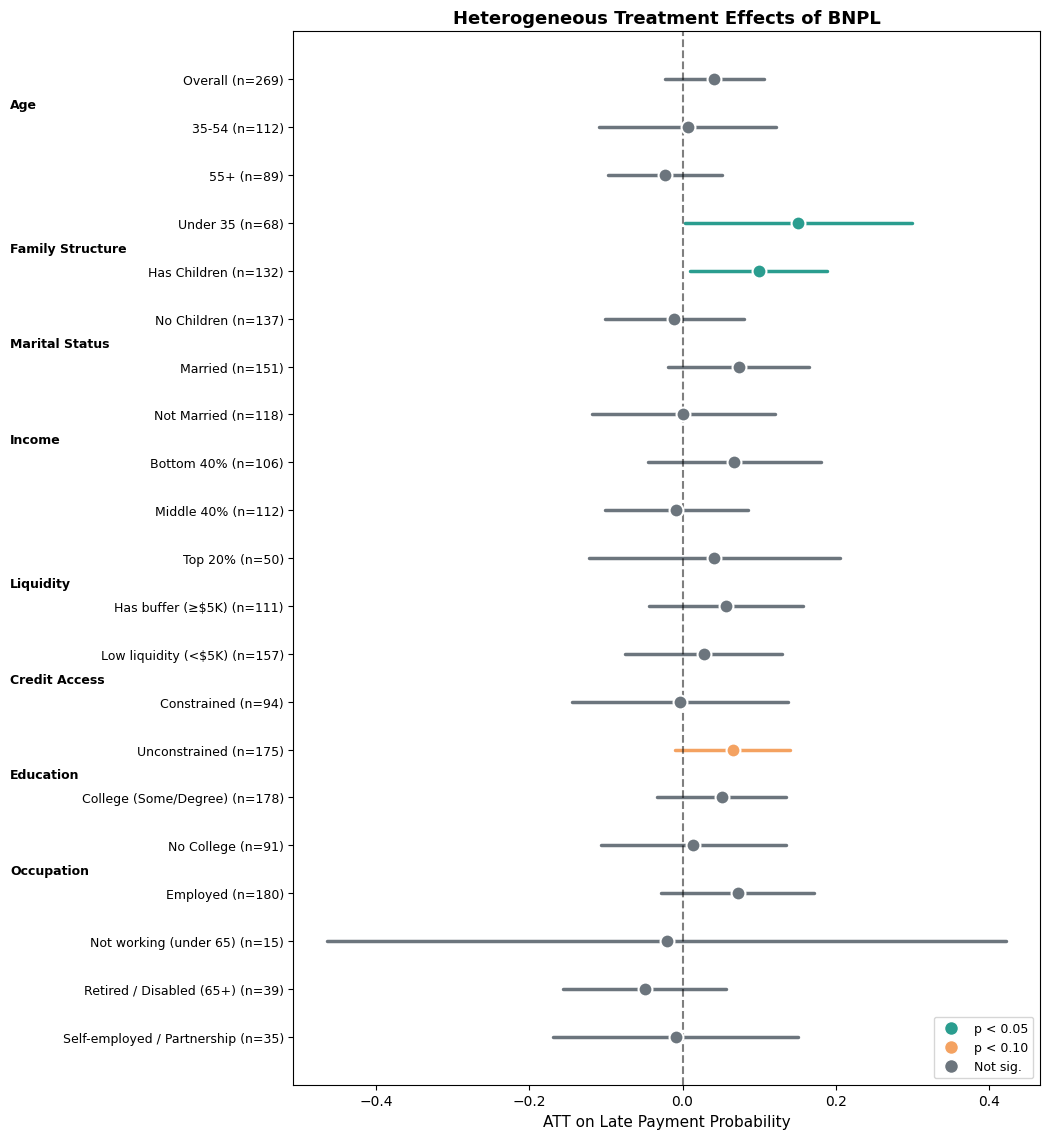

In [96]:
#  Forest Plot


def plot_forest(results_df, outcome='LATE', save_path=None):


    df_plot = results_df[results_df['Outcome'] == outcome].copy()

    dim_order = ['Overall', 'Age', 'Family Structure', 'Marital Status', 'Income',
                 'Liquidity', 'Credit Access', 'Education', 'Occupation']
    df_plot['dim_order'] = df_plot['Dimension'].map({d: i for i, d in enumerate(dim_order)})
    df_plot = df_plot.sort_values(['dim_order', 'Subgroup']).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(11, len(df_plot) * 0.5 + 1))

    y_pos = np.arange(len(df_plot))[::-1]

    for i, (_, row) in enumerate(df_plot.iterrows()):
        y = y_pos[i]

        # Color by significance
        if row['p_value'] < 0.05:
            color = '#2A9D8F'
        elif row['p_value'] < 0.1:
            color = '#F4A261'
        else:
            color = '#6C757D'

        # CI and point
        ax.plot([row['CI_lower'], row['CI_upper']], [y, y],
                color=color, linewidth=2.5, solid_capstyle='round')
        ax.scatter(row['ATT'], y, color=color, s=100, zorder=5,
                   edgecolor='white', linewidth=1.5)

    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)

    # Labels
    labels = []
    for _, row in df_plot.iterrows():
        if row['Dimension'] == 'Overall':
            labels.append(f"Overall (n={int(row['n_treated'])})")
        else:
            labels.append(f"  {row['Subgroup']} (n={int(row['n_treated'])})")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('ATT on Late Payment Probability', fontsize=11)
    ax.set_title('Heterogeneous Treatment Effects of BNPL', fontsize=13, fontweight='bold')

    # Dimension headers
    prev_dim = None
    for i, (_, row) in enumerate(df_plot.iterrows()):
        if row['Dimension'] != prev_dim and row['Dimension'] != 'Overall':
            ax.text(-0.38, y_pos[i] + 0.4, row['Dimension'],
                    transform=ax.get_yaxis_transform(),
                    fontweight='bold', fontsize=9, ha='left')
            prev_dim = row['Dimension']

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#2A9D8F', markersize=10, label='p < 0.05'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#F4A261', markersize=10, label='p < 0.10'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#6C757D', markersize=10, label='Not sig.'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()

# Generate plot
plot_forest(results_df, 'LATE', 'forest_plot_late.png')

In [97]:
# Export Results


results_df.to_csv('aipw_results.csv', index=False)
late_results.to_csv('aipw_late_results.csv', index=False)


In [98]:

# Overall ATT
print("\nOverall ATT:")
for outcome in ['LATE', 'LATE60', 'CCBAL']:
    if outcome in aipw_overall:
        r = aipw_overall[outcome]
        sig = "**" if r['p_value'] < 0.05 else ("*" if r['p_value'] < 0.1 else "")
        if outcome == 'CCBAL':
            print(f"  {outcome}: ${r['estimate']:,.0f} (SE = ${r['se']:,.0f}) {sig}")
        else:
            print(f"  {outcome}: {r['estimate']:.4f} (SE = {r['se']:.4f}) {sig}")

# Key heterogeneity
print("\nKey Heterogeneous Effects (LATE):")
key_groups = [('Age', 'Under 35'), ('Family Structure', 'Has Children'),
              ('Credit Access', 'Unconstrained')]
for dim, subgroup in key_groups:
    row = late_results[(late_results['Dimension'] == dim) &
                       (late_results['Subgroup'] == subgroup)]
    if len(row) > 0:
        r = row.iloc[0]
        sig = "**" if r['p_value'] < 0.05 else ("*" if r['p_value'] < 0.1 else "")
        print(f"  {subgroup}: {r['ATT']:.4f} (SE = {r['SE']:.4f}) {sig}")


Overall ATT:
  LATE: 0.0415 (SE = 0.0330) 
  LATE60: 0.0328 (SE = 0.0257) 
  CCBAL: $5,030 (SE = $1,382) **

Key Heterogeneous Effects (LATE):
  Under 35: 0.1511 (SE = 0.0756) **
  Has Children: 0.0995 (SE = 0.0456) **
  Unconstrained: 0.0654 (SE = 0.0385) *


Causal Forests

In [45]:
pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.50.0
    Uninstalling shap-0.50.0:
      Successfully uninstalled shap-0.50.0


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


try:
    from econml.dml import CausalForestDML
    from econml.grf import CausalForest
    print("econml imported successfully")
except ImportError:
    print("Installing econml...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'econml', '-q'])
    from econml.dml import CausalForestDML
    from econml.grf import CausalForest
    print("econml installed and imported")


In [57]:
# Base covariates
COVARIATES_BASE = [
    'AGE', 'AGE_sq',           # Demographics (age + quadratic)
    'log_income',              # Financial position
    'TURNFEAR',                # Credit constraints
    'EDCL',                    # Education
    'OCCAT1',                  # Occupation
    'MARRIED',                 # Marital status
    'KIDS'                     # Children
]

# Outcome-specific covariates
COVARIATES_BY_OUTCOME = {
    'LATE':   COVARIATES_BASE + ['log_liq', 'log_ccbal'],  # Full set
    'LATE60': COVARIATES_BASE + ['log_liq', 'log_ccbal'],  # Full set
    'CCBAL':  COVARIATES_BASE + ['log_liq'],               # Exclude log_ccbal
    'DEBT':   COVARIATES_BASE + ['log_liq', 'log_ccbal'],  # Full set
    'LIQ':    COVARIATES_BASE + ['log_ccbal'],             # Exclude log_liq
}

# Outcomes
OUTCOMES = ['LATE', 'LATE60', 'CCBAL', 'DEBT', 'LIQ']

# Subgroup dimensions
SUBGROUP_VARS = {
    'age_group': 'Age',
    'inc_group': 'Income',
    'liq_group': 'Liquidity',
    'edu_group': 'Education',
    'occ_group': 'Occupation',
    'credit_group': 'Credit Access',
    'family_group': 'Family Structure',
    'married_group': 'Marital Status'
}



# CausalForestDML Wrapper (Corrected)


class CausalForestEstimator:


    def __init__(self, n_estimators=500, min_samples_leaf=20, max_depth=10,
                 random_state=42):
        self.n_estimators = n_estimators
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.random_state = random_state
        self.model = None
        self.feature_names_ = None
        self._X_train = None
        self._T_train = None
        self._W_train = None

    def fit(self, X, Y, T, W=None, feature_names=None):

        X = np.asarray(X)
        Y = np.asarray(Y).ravel()
        T = np.asarray(T).ravel()

        self.feature_names_ = feature_names
        self._X_train = X
        self._T_train = T
        self._W_train = W


        self.model = CausalForestDML(
            model_y=RandomForestRegressor(
                n_estimators=100, max_depth=6, min_samples_leaf=20,
                random_state=self.random_state
            ),
            model_t=RandomForestRegressor(
                n_estimators=100, max_depth=6, min_samples_leaf=20,
                random_state=self.random_state
            ),
            n_estimators=self.n_estimators,
            min_samples_leaf=self.min_samples_leaf,
            max_depth=self.max_depth,
            random_state=self.random_state,
            cv=3
        )

        # Fit the model
        if W is not None:
            self.model.fit(Y, T, X=X, sample_weight=W)
        else:
            self.model.fit(Y, T, X=X)

        return self

    def predict(self, X):

        return self.model.effect(X).ravel()

    def predict_interval(self, X, alpha=0.05):

        effects = self.model.effect(X).ravel()
        try:
            lb, ub = self.model.effect_interval(X, alpha=alpha)
            return effects, lb.ravel(), ub.ravel()
        except Exception:

            se = np.std(effects) / np.sqrt(len(effects))
            z = stats.norm.ppf(1 - alpha/2)
            return effects, effects - z*se, effects + z*se

    def ate(self, X=None, W=None):

        if X is None:
            X = self._X_train
        effects = self.predict(X)

        if W is None:
            ate = np.mean(effects)
            se = np.std(effects) / np.sqrt(len(effects))
        else:
            ate = np.average(effects, weights=W)

            se = np.sqrt(np.average((effects - ate)**2, weights=W) / len(effects))

        return {'estimate': ate, 'se': se}

    def att(self, X, T, W=None):

        effects = self.predict(X)
        T = np.asarray(T).ravel()
        treated_mask = T == 1

        if W is None:
            att = np.mean(effects[treated_mask])
            se = np.std(effects[treated_mask]) / np.sqrt(treated_mask.sum())
        else:
            W = np.asarray(W)
            att = np.average(effects[treated_mask], weights=W[treated_mask])
            se = np.sqrt(np.average((effects[treated_mask] - att)**2,
                                    weights=W[treated_mask]) / treated_mask.sum())

        return {'estimate': att, 'se': se, 'n_treated': treated_mask.sum()}

    def feature_importance(self):
        """Feature importance for heterogeneity."""
        importance = self.model.feature_importances_
        if self.feature_names_ is not None:
            return pd.DataFrame({
                'Feature': self.feature_names_,
                'Importance': importance
            }).sort_values('Importance', ascending=False)
        return importance



# Implicate-Aware Estimation


def cf_with_implicates(df, outcome, covariates, n_implicates=5, weight_col='WGT'):
    """
    Runs Causal Forest across all implicates and combines results.

    """
    estimates = []
    variances = []
    n_treated_total = 0

    for imp in range(1, n_implicates + 1):
        # Filter to implicate
        df_imp = df[df['Y1'] % 10 == imp].copy()

        # Prepare data
        X = df_imp[covariates].values
        Y = df_imp[outcome].values
        T = df_imp['bnpl_user'].values
        W = df_imp[weight_col].values if weight_col in df_imp.columns else None

        # Drop missing
        valid = ~(np.isnan(X).any(axis=1) | np.isnan(Y))
        X, Y, T = X[valid], Y[valid], T[valid]
        if W is not None:
            W = W[valid]

        if T.sum() < 20:  # Need minimum treated
            continue

        # Fit model
        cf = CausalForestEstimator(n_estimators=300, min_samples_leaf=20, max_depth=8)
        cf.fit(X, Y, T, W, feature_names=covariates)

        # Get ATT
        att_result = cf.att(X, T, W)
        estimates.append(att_result['estimate'])
        variances.append(att_result['se']**2)
        n_treated_total += att_result['n_treated']

    if len(estimates) == 0:
        return None

    # Combine using Rubin's rules
    m = len(estimates)
    mean_est = np.mean(estimates)


    within_var = np.mean(variances)


    between_var = np.var(estimates, ddof=1) if m > 1 else 0

    total_var = within_var + (1 + 1/m) * between_var
    se = np.sqrt(total_var)

    # Confidence interval and p-value
    z = 1.96
    ci_lower = mean_est - z * se
    ci_upper = mean_est + z * se
    t_stat = mean_est / se if se > 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(np.abs(t_stat)))

    return {
        'estimate': mean_est,
        'se': se,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'p_value': p_value,
        'n_treated': n_treated_total // m,
        'n_implicates': m
    }


def cf_cate_by_subgroup(df, outcome, covariates, subgroup_var,
                        n_implicates=5, weight_col='WGT'):
    """
    Compute CATE for each subgroup using Causal Forest.
    Returns dictionary of results by subgroup.
    """
    results = {}

    for group in df[subgroup_var].dropna().unique():
        df_sub = df[df[subgroup_var] == group].copy()

        if df_sub['bnpl_user'].sum() < 10:
            continue

        result = cf_with_implicates(df_sub, outcome, covariates,
                                    n_implicates, weight_col)
        if result is not None:
            results[group] = result

    return results



# Single Implicate Analysis

def run_single_implicate_cf(df, outcome, covariates, implicate=1, weight_col='WGT'):
    """
    Runs Causal Forest on a single implicate.

    """
    # Filter to implicate
    df_imp = df[df['Y1'] % 10 == implicate].copy()

    X = df_imp[covariates].values
    Y = df_imp[outcome].values
    T = df_imp['bnpl_user'].values
    W = df_imp[weight_col].values if weight_col in df_imp.columns else None

    # Drop missing
    valid = ~(np.isnan(X).any(axis=1) | np.isnan(Y))
    X, Y, T = X[valid], Y[valid], T[valid]
    if W is not None:
        W = W[valid]
    df_valid = df_imp[valid].copy().reset_index(drop=True)

    print(f"  N = {len(Y)}, Treated = {T.sum()}, Control = {(1-T).sum()}")

    # Fit model
    cf = CausalForestEstimator(n_estimators=500, min_samples_leaf=20, max_depth=10)
    cf.fit(X, Y, T, W, feature_names=covariates)

    # Predict CATE with intervals
    cate, cate_lb, cate_ub = cf.predict_interval(X, alpha=0.05)

    # Add to dataframe
    df_valid['cate'] = cate
    df_valid['cate_lb'] = cate_lb
    df_valid['cate_ub'] = cate_ub

    return cf, df_valid




def run_overall_cf(df, outcomes, covariates_by_outcome):
    """Runs Causal Forest for all outcomes with implicate combination."""

    print("\n" + "="*70)
    print("OVERALL ATT ESTIMATES (Causal Forest)")
    print("="*70)
    print(f"{'Outcome':<10} {'ATT':>12} {'SE':>10} {'95% CI':<24} {'p-value':>10}")
    print("-"*70)

    cf_overall = {}

    for outcome in outcomes:
        if outcome not in df.columns:
            print(f"{outcome:<10} — not found in data")
            continue

        # Use outcome-specific covariates
        covariates = covariates_by_outcome[outcome]
        result = cf_with_implicates(df, outcome, covariates)

        if result is not None:
            cf_overall[outcome] = result

            sig = "***" if result['p_value'] < 0.01 else (
                  "**" if result['p_value'] < 0.05 else (
                  "*" if result['p_value'] < 0.1 else ""))
            ci = f"[{result['ci_lower']:.4f}, {result['ci_upper']:.4f}]"

            print(f"{outcome:<10} {result['estimate']:>12.4f} {result['se']:>10.4f} "
                  f"{ci:<24} {result['p_value']:>9.4f} {sig}")

    print("-"*70)
    print("*** p<0.01, ** p<0.05, * p<0.1")

    return cf_overall


# Full Heterogeneity Analysis


def run_full_cf_hte(df, outcomes, covariates_by_outcome, subgroup_vars):
    """Run Causal Forest for all outcomes and subgroups."""
    all_results = []

    for outcome in outcomes:
        if outcome not in df.columns:
            continue

        covariates = covariates_by_outcome[outcome]
        print(f"\nProcessing {outcome} ({len(covariates)} covariates)...")

        # Overall
        overall = cf_with_implicates(df, outcome, covariates)
        if overall:
            all_results.append({
                'Outcome': outcome,
                'Dimension': 'Overall',
                'Subgroup': 'All',
                'ATT': overall['estimate'],
                'SE': overall['se'],
                'CI_lower': overall['ci_lower'],
                'CI_upper': overall['ci_upper'],
                'p_value': overall['p_value'],
                'n_treated': overall['n_treated']
            })

        # By subgroup
        for var, label in subgroup_vars.items():
            if var not in df.columns:
                continue

            print(f"  - {label}")
            cates = cf_cate_by_subgroup(df, outcome, covariates, var)

            for group, result in cates.items():
                all_results.append({
                    'Outcome': outcome,
                    'Dimension': label,
                    'Subgroup': group,
                    'ATT': result['estimate'],
                    'SE': result['se'],
                    'CI_lower': result['ci_lower'],
                    'CI_upper': result['ci_upper'],
                    'p_value': result['p_value'],
                    'n_treated': result['n_treated']
                })

    return pd.DataFrame(all_results)



# GATE Analysis


def compute_gate(df_with_cate, n_quantiles=4):

    df = df_with_cate.copy()

    # Create CATE quantiles
    labels = [f'Q{i+1}' for i in range(n_quantiles)]
    labels[0] = 'Q1 (Lowest)'
    labels[-1] = f'Q{n_quantiles} (Highest)'

    df['cate_quantile'] = pd.qcut(df['cate'], q=n_quantiles, labels=labels)

    gate_results = []
    for q in labels:
        mask = df['cate_quantile'] == q
        q_cates = df.loc[mask, 'cate']
        n_treated = (df.loc[mask, 'bnpl_user'] == 1).sum()
        n_total = mask.sum()

        mean_cate = q_cates.mean()

        # Bootstrap SE for proper inference
        n_boot = 500
        boot_means = []
        for _ in range(n_boot):
            boot_idx = np.random.choice(len(q_cates), size=len(q_cates), replace=True)
            boot_means.append(q_cates.iloc[boot_idx].mean())
        se_cate = np.std(boot_means)

        # p-value
        t_stat = mean_cate / se_cate if se_cate > 0 else 0
        p_value = 2 * (1 - stats.norm.cdf(np.abs(t_stat)))

        gate_results.append({
            'Quantile': q,
            'Mean_CATE': mean_cate,
            'SE': se_cate,
            'CI_lower': mean_cate - 1.96*se_cate,
            'CI_upper': mean_cate + 1.96*se_cate,
            'p_value': p_value,
            'N': n_total,
            'N_Treated': n_treated
        })

    return pd.DataFrame(gate_results)



# Visualization Functions


def plot_cate_distribution(df_with_cate, outcome='LATE', save_path=None):
    """Plot distribution of individual treatment effects."""
    fig, ax = plt.subplots(figsize=(10, 6))

    cate = df_with_cate['cate']

    ax.hist(cate, bins=50, edgecolor='white', alpha=0.7, color='#2A9D8F')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Zero Effect')
    ax.axvline(x=cate.mean(), color='#E63946', linestyle='-', linewidth=2,
               label=f'ATE = {cate.mean():.3f}')

    ax.set_xlabel('Conditional Average Treatment Effect (CATE)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'Distribution of Individual Treatment Effects ({outcome})',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)

    # Add summary stats
    textstr = f'Mean: {cate.mean():.4f}\nStd: {cate.std():.4f}\n% Positive: {100*(cate>0).mean():.1f}%'
    ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()


def plot_gate(gate_df, outcome='LATE', save_path=None):
    """Plot GATE analysis results."""
    fig, ax = plt.subplots(figsize=(8, 5))

    quartiles = gate_df['Quantile'].values
    means = gate_df['Mean_CATE'].values
    ses = gate_df['SE'].values

    colors = ['#2A9D8F' if m < 0 else '#E63946' for m in means]
    bars = ax.bar(range(len(quartiles)), means, yerr=1.96*ses, capsize=5,
                  color=colors, edgecolor='white', linewidth=1.5)

    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('Group Average Treatment Effect', fontsize=12)
    ax.set_xlabel('CATE Quartile', fontsize=12)
    ax.set_title(f'Treatment Effect Heterogeneity ({outcome})',
                 fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(quartiles)))
    ax.set_xticklabels([q.replace(' ', '\n') for q in quartiles])

    for bar, mean in zip(bars, means):
        ypos = bar.get_height() + 0.01 if mean >= 0 else bar.get_height() - 0.02
        ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{mean:.3f}',
                ha='center', va='bottom' if mean >= 0 else 'top', fontsize=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()


def plot_variable_importance(importance_df, save_path=None):

    fig, ax = plt.subplots(figsize=(10, 6))

    imp_sorted = importance_df.sort_values('Importance', ascending=True)
    ax.barh(imp_sorted['Feature'], imp_sorted['Importance'],
            color='#457B9D', edgecolor='white')
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title('Heterogeneity Drivers (Variable Importance)',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()


def plot_forest_cf(results_df, outcome='LATE', save_path=None):


    df_plot = results_df[results_df['Outcome'] == outcome].copy()

    dim_order = ['Overall', 'Age', 'Family Structure', 'Marital Status', 'Income',
                 'Liquidity', 'Credit Access', 'Education', 'Occupation']
    df_plot['dim_order'] = df_plot['Dimension'].map({d: i for i, d in enumerate(dim_order)})
    df_plot = df_plot.sort_values(['dim_order', 'Subgroup']).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(11, len(df_plot) * 0.5 + 1))

    y_pos = np.arange(len(df_plot))[::-1]

    for i, (_, row) in enumerate(df_plot.iterrows()):
        y = y_pos[i]

        if row['p_value'] < 0.05:
            color = '#2A9D8F'
        elif row['p_value'] < 0.1:
            color = '#F4A261'
        else:
            color = '#6C757D'

        ax.plot([row['CI_lower'], row['CI_upper']], [y, y],
                color=color, linewidth=2.5, solid_capstyle='round')
        ax.scatter(row['ATT'], y, color=color, s=100, zorder=5,
                   edgecolor='white', linewidth=1.5)

    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)

    labels = []
    for _, row in df_plot.iterrows():
        if row['Dimension'] == 'Overall':
            labels.append(f"Overall (n={int(row['n_treated'])})")
        else:
            labels.append(f"  {row['Subgroup']} (n={int(row['n_treated'])})")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel(f'CATE on {outcome}', fontsize=11)
    ax.set_title('Causal Forest: Heterogeneous Treatment Effects',
                 fontsize=13, fontweight='bold')

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#2A9D8F',
               markersize=10, label='p < 0.05'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#F4A261',
               markersize=10, label='p < 0.10'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#6C757D',
               markersize=10, label='Not sig.'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()



# Method Comparison Function


def compare_cf_aipw(cf_results, aipw_results, outcome='LATE'):
    """
    Compare Causal Forest vs AIPW results side by side.
    """
    print("\n" + "="*90)
    print(f"COMPARISON: Causal Forest vs AIPW ({outcome})")
    print("="*90)

    cf_out = cf_results[cf_results['Outcome'] == outcome].copy()
    aipw_out = aipw_results[aipw_results['Outcome'] == outcome].copy()


    merged = cf_out.merge(aipw_out, on=['Dimension', 'Subgroup'],
                          suffixes=('_CF', '_AIPW'), how='outer')

    print(f"\n{'Dimension':<15} {'Subgroup':<20} {'CF ATT':>10} {'AIPW ATT':>10} {'Diff':>10}")
    print("-"*70)

    for _, row in merged.iterrows():
        cf_att = row.get('ATT_CF', np.nan)
        aipw_att = row.get('ATT_AIPW', np.nan)
        diff = cf_att - aipw_att if pd.notna(cf_att) and pd.notna(aipw_att) else np.nan

        cf_str = f"{cf_att:.4f}" if pd.notna(cf_att) else "—"
        aipw_str = f"{aipw_att:.4f}" if pd.notna(aipw_att) else "—"
        diff_str = f"{diff:.4f}" if pd.notna(diff) else "—"

        print(f"{row['Dimension']:<15} {row['Subgroup']:<20} {cf_str:>10} {aipw_str:>10} {diff_str:>10}")

    return merged



# Main Execution


def run_causal_forest_analysis(df, aipw_results_df=None):



    for outcome, covs in COVARIATES_BY_OUTCOME.items():
        COVARIATES_BY_OUTCOME[outcome] = [c for c in covs if c in df.columns]

    print(f"\nData: {len(df)} observations, {df['bnpl_user'].sum()} BNPL users")
    print(f"Outcomes: {OUTCOMES}")
    print(f"Subgroups: {list(SUBGROUP_VARS.values())}")


    cf_overall = run_overall_cf(df, OUTCOMES, COVARIATES_BY_OUTCOME)


    print("\n" + "="*70)
    print("RUNNING FULL HETEROGENEITY ANALYSIS")
    print("="*70)

    cf_results_df = run_full_cf_hte(df, OUTCOMES, COVARIATES_BY_OUTCOME, SUBGROUP_VARS)
    cf_results_df['Sig'] = cf_results_df['p_value'].apply(
        lambda x: '***' if x < 0.01 else ('**' if x < 0.05 else ('*' if x < 0.1 else ''))
    )

    print(f"\n✓ Complete! Total estimates: {len(cf_results_df)}")


    print("\n" + "="*70)
    print("CATE DISTRIBUTION ANALYSIS (Single Implicate)")
    print("="*70)

    covariates_late = COVARIATES_BY_OUTCOME['LATE']
    cf_model, df_cf = run_single_implicate_cf(df, 'LATE', covariates_late, implicate=1)

    cate = df_cf['cate']
    print(f"\nCATE Distribution:")
    print(f"  Mean (ATE):    {cate.mean():.4f}")
    print(f"  Median:        {np.median(cate):.4f}")
    print(f"  Std Dev:       {cate.std():.4f}")
    print(f"  Min:           {cate.min():.4f}")
    print(f"  Max:           {cate.max():.4f}")
    print(f"  % Positive:    {100 * (cate > 0).mean():.1f}%")


    print("\n" + "="*70)
    print("VARIABLE IMPORTANCE (Heterogeneity Drivers)")
    print("="*70)

    importance_df = cf_model.feature_importance()
    print(f"\n{'Rank':<6} {'Feature':<15} {'Importance':>12}")
    print("-"*35)
    for i, (_, row) in enumerate(importance_df.iterrows(), 1):
        print(f"{i:<6} {row['Feature']:<15} {row['Importance']:>12.4f}")


    print("\n" + "="*70)
    print("GATE ANALYSIS (Effect Heterogeneity by CATE Quartile)")
    print("="*70)

    gate_df = compute_gate(df_cf, n_quantiles=4)

    print(f"\n{'Quartile':<15} {'Mean CATE':>12} {'SE':>10} {'N':>8} {'N Treated':>10}")
    print("-"*60)
    for _, row in gate_df.iterrows():
        print(f"{row['Quantile']:<15} {row['Mean_CATE']:>12.4f} {row['SE']:>10.4f} "
              f"{row['N']:>8} {row['N_Treated']:>10}")

    q1_mean = gate_df.loc[gate_df['Quantile'] == 'Q1 (Lowest)', 'Mean_CATE'].values[0]
    q4_mean = gate_df.loc[gate_df['Quantile'] == 'Q4 (Highest)', 'Mean_CATE'].values[0]

    print(f"\nKey Insight:")
    print(f"  Bottom 25% (protected): CATE = {q1_mean:.4f} ({q1_mean*100:.1f} pp)")
    print(f"  Top 25% (harmed):       CATE = {q4_mean:.4f} ({q4_mean*100:.1f} pp)")
    print(f"  Heterogeneity range:    {(q4_mean - q1_mean)*100:.1f} pp")



    plot_cate_distribution(df_cf, 'LATE', 'cf_cate_distribution.png')
    plot_gate(gate_df, 'LATE', 'cf_gate_analysis.png')
    plot_variable_importance(importance_df, 'cf_variable_importance.png')
    plot_forest_cf(cf_results_df, 'LATE', 'cf_forest_plot_late.png')


    if aipw_results_df is not None:
        comparison_df = compare_cf_aipw(cf_results_df, aipw_results_df, 'LATE')
        comparison_df.to_csv('cf_vs_aipw_comparison.csv', index=False)


    cf_results_df.to_csv('cf_results.csv', index=False)
    gate_df.to_csv('cf_gate_results.csv', index=False)
    importance_df.to_csv('cf_variable_importance.csv', index=False)

    late_results = cf_results_df[cf_results_df['Outcome'] == 'LATE']
    late_results.to_csv('cf_late_results.csv', index=False)


    print("\n" + "="*70)
    print("CAUSAL FOREST ANALYSIS COMPLETE")
    print("="*70)

    print("\n1. METHOD: CausalForestDML (Athey-Wager)")
    print("   - Doubly robust (uses propensity + outcome models)")
    print("   - Splits on treatment effect heterogeneity")
    print("   - Valid for imbalanced treatment")

    print(f"\n2. OVERALL EFFECTS:")
    for outcome in ['LATE', 'LATE60', 'CCBAL']:
        if outcome in cf_overall:
            r = cf_overall[outcome]
            sig = "**" if r['p_value'] < 0.05 else ("*" if r['p_value'] < 0.1 else "")
            if outcome == 'CCBAL':
                print(f"   {outcome}: ${r['estimate']:,.0f} (SE = ${r['se']:,.0f}) {sig}")
            else:
                print(f"   {outcome}: {r['estimate']:.4f} (SE = {r['se']:.4f}) {sig}")

    print(f"\n3. HETEROGENEITY (GATE):")
    print(f"   Q1 (Protected): {q1_mean:.4f}")
    print(f"   Q4 (Harmed):    {q4_mean:.4f}")
    print(f"   Range:          {(q4_mean - q1_mean)*100:.1f} pp")

    print("\n4. TOP HETEROGENEITY DRIVERS:")
    for i, (_, row) in enumerate(importance_df.head(3).iterrows(), 1):
        print(f"   {i}. {row['Feature']}: {row['Importance']:.4f}")

    return {
        'cf_overall': cf_overall,
        'cf_results_df': cf_results_df,
        'cf_model': cf_model,
        'df_cf': df_cf,
        'gate_df': gate_df,
        'importance_df': importance_df
    }





econml imported successfully
CAUSAL FOREST ANALYSIS (econml CausalForestDML)


In [ ]:
cf_outputs = run_causal_forest_analysis(df, aipw_results_df=results_df)

In [ ]:
cf_results = cf_outputs['cf_results_df']
gate_results = cf_outputs['gate_df']
importance = cf_outputs['importance_df']